# Module A: Predictor (A1–A6)

**Action-Conditioned JEPA World Model — Predictor Baselines & Ablations**

| # | Task | Detail |
|---|------|--------|
| A1 | Transformer predictor | Causal Transformer (4 layers, d=256, 4 heads, Action MLP) |
| A2 | Context ablation $T\in\{1,2,4,8\}$ | Train Transformer $K{=}1$ for each $T$, plot results |
| A3 | MLP vs Transformer comparison | val cos_sim vs epoch for both at $K{=}1$ |
| A4 | Multi-horizon $K\in\{5,10,20\}$ | Train best predictor (Transformer, best $T$) for each $K$ |
| A5 | Rollout drift evaluation | Autoregressive rollout: cos(ẑ, z*) vs step $k$ for each $K$ |
| A6 | Action grounding ablation | Zero action / random action / full action |

**Dataset**: Robomimic Lift (ph), ~9.7k frames, pre-embedded with frozen DINOv2 ViT-S/14.
All embeddings cached in `data/embeddings/`.

## Section 1: Setup & Imports

In [17]:
import sys
import subprocess

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

for pkg in ['torch>=2.0', 'matplotlib', 'scikit-learn', 'tqdm', 'numpy', 'pillow']:
    pip_install(pkg)

import os, json, math, random, copy
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ── Paths (Colab-aware) ──
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/content/drive/MyDrive/jepa_action')
    print('Mounted Google Drive. Make sure data/ is at MyDrive/jepa_action/data/')
except ImportError:
    ROOT = Path(os.getcwd()).resolve()
    if not (ROOT / 'data' / 'embeddings').exists():
        if (ROOT.parent / 'data' / 'embeddings').exists():
            ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'outputs'
EMBED_DIR = DATA_DIR / 'embeddings'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Config ──
class Config:
    embed_dim = 384
    action_dim = 7
    d_model = 256
    n_heads = 4
    n_layers = 4
    action_hidden = 128          # Action MLP hidden dim
    batch_size = 1024      # Colab L4: 24GB VRAM
    learning_rate = 1e-4
    weight_decay = 0.05
    warmup_steps = 500
    max_epochs = 50
    use_amp = True
    dropout = 0.2
    mlp_hidden = [512, 256]
    seed = 42
    K_values = [1, 5, 10, 20]
    T_values = [1, 2, 4, 8]      # context window sizes
    num_train_demos = 160
    num_val_demos = 40

cfg = Config()

# ── Device & reproducibility ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    gpu_name = torch.cuda.get_device_name(0)
    # gpu_mem = torch.cuda.get_device_properties(0).total_mem / 1e9
    # print(f'GPU: {gpu_name} ({gpu_mem:.1f} GB)')
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(cfg.seed)
    torch.backends.cudnn.benchmark = True

print('Setup complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted Google Drive. Make sure data/ is at MyDrive/jepa_action/data/
Device: cuda
Setup complete.


## Section 2: Load Cached Embeddings & Triplets

In [18]:
train_embeddings = torch.load(EMBED_DIR / 'embeddings_train.pt').float()
val_embeddings = torch.load(EMBED_DIR / 'embeddings_val.pt').float()
train_actions = torch.load(EMBED_DIR / 'actions_train.pt').float()
val_actions = torch.load(EMBED_DIR / 'actions_val.pt').float()
norm_stats = torch.load(EMBED_DIR / 'norm_stats.pt')

triplets = {}
for K in cfg.K_values:
    triplets[f'train_K{K}'] = torch.load(EMBED_DIR / f'triplets_train_K{K}.pt')
    triplets[f'val_K{K}'] = torch.load(EMBED_DIR / f'triplets_val_K{K}.pt')

print(f'Train embeddings: {train_embeddings.shape}')
print(f'Val embeddings:   {val_embeddings.shape}')
print(f'Train actions:     {train_actions.shape}')
for K in cfg.K_values:
    print(f'  K={K}: train={len(triplets[f"train_K{K}"]):,}, val={len(triplets[f"val_K{K}"]):,}')

mean_embed = train_embeddings.mean(dim=0, keepdim=True)

Train embeddings: torch.Size([3901, 384])
Val embeddings:   torch.Size([984, 384])
Train actions:     torch.Size([3901, 7])
  K=1: train=3,741, val=944
  K=5: train=3,101, val=784
  K=10: train=2,301, val=584
  K=20: train=712, val=186


## Section 3: Context Triplet Dataset (for $T \ge 1$)

For a given context window $T$, each sample produces:
- `embeds`: $[z_{t-T+1}, \ldots, z_t]$ — shape $(T, 384)$
- `actions`: $[a_{t-T+1}, \ldots, a_t]$ — shape $(T, 7)$  
- `target`: $z_{t+K}$ — shape $(384,)$

The triplet index `triplets[idx] = [idx_t, idx_a, idx_tpk]` maps to the **last** context timestep $t$ and the target $t+K$. We then look back $T-1$ steps.

In [19]:
class ContextTripletDataset(Dataset):
    """Produces (B, T, 384), (B, T, 7), (B, 384) for Transformer with context T.
    For T=1, this degenerates to the original single-frame dataset."""
    def __init__(self, embed_path, action_path, triplet_path, T=1):
        self.embeddings = torch.load(embed_path)
        self.actions = torch.load(action_path)
        self.triplets = torch.load(triplet_path)
        self.T = T
        # Keep only triplets where t >= T-1 (enough history)
        valid = self.triplets[:, 0] >= (T - 1)
        self.triplets = self.triplets[valid]

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        t_idx, a_idx, tpK_idx = self.triplets[idx]
        # Context window: t-T+1 to t
        z_seq = self.embeddings[t_idx - self.T + 1 : t_idx + 1]  # (T, 384)
        a_seq = self.actions[t_idx - self.T + 1 : t_idx + 1]      # (T, 7)
        target = self.embeddings[tpK_idx]                          # (384,)
        if z_seq.shape[0] < self.T:
            pad = self.T - z_seq.shape[0]
            z_seq = torch.cat([torch.zeros(pad, self.embeddings.shape[1]), z_seq], dim=0)
            a_seq = torch.cat([torch.zeros(pad, self.actions.shape[1]), a_seq], dim=0)
        return z_seq, a_seq, target

print('ContextTripletDataset defined.')

ContextTripletDataset defined.


## Section 4: Models

### 4.1 MLP Predictor (Baseline)
Concatenate $z_t$ and $a_t$; MLP $[384{+}7 \to 512 \to 256 \to 384]$.

In [20]:
class MLPPredictor(nn.Module):
    def __init__(self, embed_dim=384, action_dim=7, hidden_dims=[512,256]):
        super().__init__()
        layers = []
        in_dim = embed_dim + action_dim
        for h in hidden_dims:
            layers.extend([nn.Linear(in_dim, h), nn.ReLU()])
            in_dim = h
        layers.append(nn.Linear(in_dim, embed_dim))
        self.fc = nn.Sequential(*layers)

    def forward(self, embeds, actions):
        """embeds: (B, 384) or (B, T, 384); actions: (B, 7) or (B, T, 7)"""
        if embeds.dim() == 3:  # use last frame for T>1
            embeds = embeds[:, -1, :]
            actions = actions[:, -1, :]
        x = torch.cat([embeds, actions], dim=-1)
        return self.fc(x)

print(f'MLP params: {sum(p.numel() for p in MLPPredictor().parameters()):,}')

MLP params: 430,720


### 4.2 Transformer Predictor (A1)

Per Section 7.2 of the plan:
1. Project $z_t$ via `Linear(384, 256)`
2. Encode $a_t$ through **Action MLP** ($\mathbb{R}^7 \to 128 \to d_{model}=256$)
3. Add sinusoidal position encoding
4. Causal Transformer Encoder (4 layers, $d_{model}=256$, 4 heads)
5. Predict via `Linear(256, 384)`

In [21]:
class ActionMLP(nn.Module):
    """Action MLP: R^7 → 128 → d_model (256) per Section 7.2."""
    def __init__(self, action_dim=7, hidden_dim=128, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(action_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, a):
        return self.net(a)


class TransformerPredictor(nn.Module):
    """Causal Transformer predictor for JEPA latent dynamics.
    
    Architecture per Section 7.2:
      x_t = Lin_{384→256}(z_t) + ActionMLP(a_t) + PE(t)
      Ẑ_{t+K} = Lin_{256→384}(CausalTF(x_{t-T+1:t}))
    """
    def __init__(self, embed_dim=384, action_dim=7, d_model=256,
                 n_layers=4, n_heads=4, max_seq_len=64, dropout=0.2):
        super().__init__()
        self.d_model = d_model
        self.embed_proj = nn.Linear(embed_dim, d_model)
        self.action_mlp = ActionMLP(action_dim, hidden_dim=128, out_dim=d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, max_seq_len, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, batch_first=True,
            dropout=dropout, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
        self.predictor = nn.Linear(d_model, embed_dim)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, embeds, actions):
        """
        embeds:  (B, T, 384) or (B, 384) — context embeddings
        actions: (B, T, 7)   or (B, 7)
        Returns: (B, 384)
        """
        if embeds.dim() == 2:
            embeds = embeds.unsqueeze(1)
            actions = actions.unsqueeze(1)
        B, T, _ = embeds.shape
        # x_t = Lin(z_t) + ActionMLP(a_t) + PE(t)
        x = self.embed_proj(embeds) + self.action_mlp(actions)
        x = x + self.pos_embed[:, :T, :]
        # Causal mask: token i can only attend to tokens <= i
        causal_mask = torch.triu(
            torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1
        )
        x = self.transformer(x, mask=causal_mask)
        # Predict from last token
        return self.predictor(x[:, -1, :])


print(f'Transformer params: {sum(p.numel() for p in TransformerPredictor().parameters()):,}')

Transformer params: 5,507,968


## Section 5: Training Utilities

In [22]:
def cosine_loss(pred, target):
    return 1.0 - F.cosine_similarity(pred, target, dim=-1).mean()

def get_lr(step, warmup_steps, total_steps, base_lr):
    if step < warmup_steps:
        return base_lr * step / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))

@torch.no_grad()
def compute_val_cosine(model, loader):
    model.eval()
    cs_list = []
    for z_seq, a_seq, target in loader:
        z_seq = z_seq.to(device)
        a_seq = a_seq.to(device)
        target = target.to(device)
        if cfg.use_amp and device.type == 'cuda':
            with autocast():
                pred = model(z_seq, a_seq)
        else:
            pred = model(z_seq, a_seq)
        cs = F.cosine_similarity(pred, target, dim=-1).mean().item()
        cs_list.append(cs)
    return np.mean(cs_list)

@torch.no_grad()
def compute_val_cosine_ablation(model, loader, action_mode='zero'):
    """Action ablation: 'zero', 'random', 'full'."""
    model.eval()
    cs_list = []
    for z_seq, a_seq, target in loader:
        z_seq = z_seq.to(device)
        target = target.to(device)
        if action_mode == 'zero':
            a_in = torch.zeros_like(a_seq).to(device)
        elif action_mode == 'random':
            a_in = torch.randn_like(a_seq).to(device)
        else:
            a_in = a_seq.to(device)
        if cfg.use_amp and device.type == 'cuda':
            with autocast():
                pred = model(z_seq, a_in)
        else:
            pred = model(z_seq, a_in)
        cs = F.cosine_similarity(pred, target, dim=-1).mean().item()
        cs_list.append(cs)
    return np.mean(cs_list)

def train_one_epoch(model, loader, optimizer, scaler, global_step, total_steps):
    model.train()
    epoch_loss = 0.0
    for z_seq, a_seq, target in loader:
        z_seq = z_seq.to(device)
        a_seq = a_seq.to(device)
        target = target.to(device)
        lr = get_lr(global_step, cfg.warmup_steps, total_steps, cfg.learning_rate)
        for pg in optimizer.param_groups:
            pg['lr'] = lr
        if cfg.use_amp and device.type == 'cuda':
            with autocast():
                pred = model(z_seq, a_seq)
                loss = cosine_loss(pred, target)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            pred = model(z_seq, a_seq)
            loss = cosine_loss(pred, target)
            loss.backward()
            optimizer.step()
        optimizer.zero_grad()
        epoch_loss += loss.item()
        global_step += 1
    return epoch_loss / len(loader), global_step

def build_loaders(K, T, batch_size=None):
    """Build train/val loaders for a given K and context T."""
    bs = batch_size or cfg.batch_size
    train_ds = ContextTripletDataset(
        EMBED_DIR / 'embeddings_train.pt',
        EMBED_DIR / 'actions_train.pt',
        EMBED_DIR / f'triplets_train_K{K}.pt', T=T
    )
    val_ds = ContextTripletDataset(
        EMBED_DIR / 'embeddings_val.pt',
        EMBED_DIR / 'actions_val.pt',
        EMBED_DIR / f'triplets_val_K{K}.pt', T=T
    )
    train_ldr = DataLoader(train_ds, batch_size=bs, shuffle=True,
                           num_workers=4, pin_memory=(device.type=='cuda'), drop_last=False)
    val_ldr = DataLoader(val_ds, batch_size=bs, shuffle=False,
                         num_workers=4, pin_memory=(device.type=='cuda'))
    return train_ldr, val_ldr

def train_model(model, K, T, epochs=None, verbose=False):
    """Full training loop, returns dict with results."""
    epochs = epochs or cfg.max_epochs
    train_ldr, val_ldr = build_loaders(K, T)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    scaler = GradScaler(enabled=(cfg.use_amp and device.type=='cuda'))
    total_steps = epochs * len(train_ldr)
    gs = 0
    train_losses = []
    val_cos_list = []
    best_cos = -1.0
    for epoch in range(1, epochs + 1):
        avg_loss, gs = train_one_epoch(model, train_ldr, optimizer, scaler, gs, total_steps)
        val_cos = compute_val_cosine(model, val_ldr)
        train_losses.append(avg_loss)
        val_cos_list.append(val_cos)
        if val_cos > best_cos:
            best_cos = val_cos
        if verbose or epoch % max(1, epochs // 10) == 0 or epoch == 1 or epoch == epochs:
            print(f'E {epoch:3d}/{epochs} | loss={avg_loss:.4f} | val_cos={val_cos:.4f} | best={best_cos:.4f} | lr={optimizer.param_groups[0]["lr"]:.2e}')
    return {
        'model': model, 'val_cos': val_cos_list[-1], 'best_cos': best_cos,
        'train_losses': train_losses, 'val_cos_list': val_cos_list,
        'K': K, 'T': T
    }

# ── Baselines ──
identity_score = torch.nn.functional.cosine_similarity(
    val_embeddings[:100], val_embeddings[:100], dim=-1
).mean().item()
mean_pred = mean_embed.expand(val_embeddings.shape[0], -1)
mean_score = torch.nn.functional.cosine_similarity(
    mean_pred, val_embeddings, dim=-1
).mean().item()
baselines = {'identity': identity_score, 'mean': mean_score}
print(f'Identity baseline: {baselines["identity"]:.4f}')
print(f'Mean baseline:     {baselines["mean"]:.4f}')
print('Utilities ready.')

Identity baseline: 1.0000
Mean baseline:     0.8632
Utilities ready.


────────────────────────────────────────────────────────
## A1 + A2: Transformer Context Ablation ($T \in \{1, 2, 4, 8\}$, $K=1$)
────────────────────────────────────────────────────────

Train the Transformer predictor at $K=1$ for each context window $T$, measuring val cosine similarity vs epoch.

In [23]:
print('=' * 65)
print('A1 + A2: Transformer Context Ablation T = {1, 2, 4, 8}')
print('=' * 65)

context_results = {}  # T -> result dict

for T in cfg.T_values:
    print(f'\n{"─" * 50}')
    print(f'Training Transformer with T={T} (K=1)')
    print(f'{"─" * 50}')
    model = TransformerPredictor(
        embed_dim=cfg.embed_dim, action_dim=cfg.action_dim, d_model=cfg.d_model,
        n_layers=cfg.n_layers, n_heads=cfg.n_heads, dropout=cfg.dropout,
    ).to(device)
    result = train_model(model, K=1, T=T, verbose=True)
    context_results[T] = result
    print(f'T={T} final val_cos_sim = {result["val_cos"]:.4f} (best: {result["best_cos"]:.4f})')

print('\nContext ablation complete.')

A1 + A2: Transformer Context Ablation T = {1, 2, 4, 8}

──────────────────────────────────────────────────
Training Transformer with T=1 (K=1)
──────────────────────────────────────────────────


/tmp/ipykernel_7050/1864248459.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(cfg.use_amp and device.type=='cuda'))
/tmp/ipykernel_7050/1864248459.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


E   1/50 | loss=0.9805 | val_cos=0.0293 | best=0.0293 | lr=6.00e-07


/tmp/ipykernel_7050/1864248459.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


E   2/50 | loss=0.9769 | val_cos=0.0384 | best=0.0384 | lr=1.40e-06
E   3/50 | loss=0.9702 | val_cos=0.0541 | best=0.0541 | lr=2.20e-06
E   4/50 | loss=0.9561 | val_cos=0.0762 | best=0.0762 | lr=3.00e-06
E   5/50 | loss=0.9422 | val_cos=0.1044 | best=0.1044 | lr=3.80e-06
E   6/50 | loss=0.9211 | val_cos=0.1379 | best=0.1379 | lr=4.60e-06
E   7/50 | loss=0.8976 | val_cos=0.1758 | best=0.1758 | lr=5.40e-06
E   8/50 | loss=0.8690 | val_cos=0.2170 | best=0.2170 | lr=6.20e-06
E   9/50 | loss=0.8389 | val_cos=0.2599 | best=0.2599 | lr=7.00e-06
E  10/50 | loss=0.8070 | val_cos=0.3031 | best=0.3031 | lr=7.80e-06
E  11/50 | loss=0.7722 | val_cos=0.3453 | best=0.3453 | lr=8.60e-06
E  12/50 | loss=0.7373 | val_cos=0.3857 | best=0.3857 | lr=9.40e-06
E  13/50 | loss=0.7025 | val_cos=0.4237 | best=0.4237 | lr=1.02e-05
E  14/50 | loss=0.6689 | val_cos=0.4590 | best=0.4590 | lr=1.10e-05
E  15/50 | loss=0.6352 | val_cos=0.4916 | best=0.4916 | lr=1.18e-05
E  16/50 | loss=0.6034 | val_cos=0.5217 | best=0

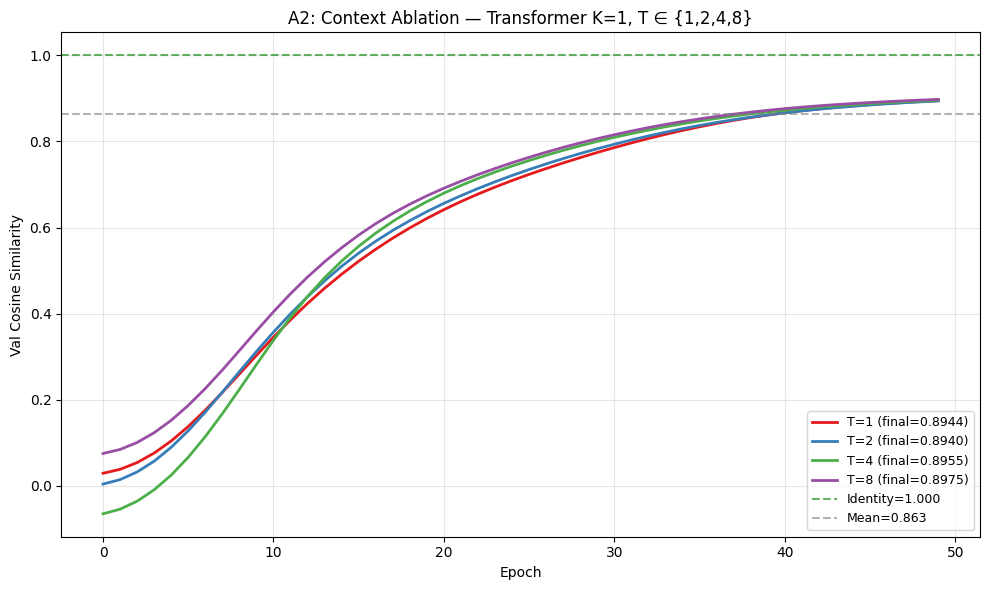

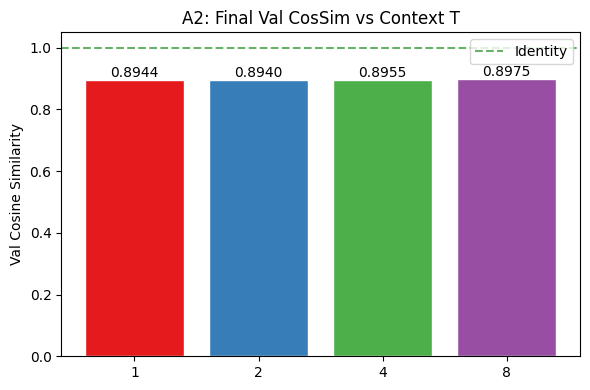

Best context window: T=8 (val_cos=0.8975)


In [24]:
# ── Plot A2: Context Ablation Curves ──
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for i, T in enumerate(cfg.T_values):
    ax.plot(context_results[T]['val_cos_list'], color=colors[i], linewidth=2,
            label=f'T={T} (final={context_results[T]["val_cos"]:.4f})')
ax.axhline(y=baselines['identity'], color='green', linestyle='--', alpha=0.6, label=f'Identity={baselines["identity"]:.3f}')
ax.axhline(y=baselines['mean'], color='gray', linestyle='--', alpha=0.6, label=f'Mean={baselines["mean"]:.3f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Cosine Similarity')
ax.set_title('A2: Context Ablation — Transformer K=1, T ∈ {1,2,4,8}')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a2_context_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart of final results
fig, ax = plt.subplots(figsize=(6, 4))
T_vals = [str(T) for T in cfg.T_values]
final_cos = [context_results[T]['val_cos'] for T in cfg.T_values]
bars = ax.bar(T_vals, final_cos, color=colors, edgecolor='white')
for bar, val in zip(bars, final_cos):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{val:.4f}',
            ha='center', va='bottom', fontsize=10)
ax.axhline(y=baselines['identity'], color='green', linestyle='--', alpha=0.6, label='Identity')
ax.set_ylabel('Val Cosine Similarity')
ax.set_title('A2: Final Val CosSim vs Context T')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a2_context_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Determine best T for later use
best_T = max(context_results, key=lambda t: context_results[t]['val_cos'])
print(f'Best context window: T={best_T} (val_cos={context_results[best_T]["val_cos"]:.4f})')

────────────────────────────────────────────────────────
## A3: MLP vs Transformer Comparison ($K=1$)
────────────────────────────────────────────────────────

Train MLP on $K=1$ (T=1) and compare convergence with the best Transformer.

In [25]:
print('=' * 65)
print('A3: MLP vs Transformer Comparison (K=1)')
print('=' * 65)

# Check for cached MLP
mlp_path = OUTPUT_DIR / 'weekend1_mlp_predictor.pt'
if mlp_path.exists():
    print('Loading cached MLP checkpoint...')
    ckpt = torch.load(mlp_path, map_location=device)
    mlp_model = MLPPredictor(cfg.embed_dim, cfg.action_dim, cfg.mlp_hidden).to(device)
    mlp_model.load_state_dict(ckpt['model_state_dict'])
    mlp_val_sim = ckpt.get('final_val_cos_sim', None)
    print(f'Loaded MLP (val_cos_sim={mlp_val_sim:.4f})')
    mlp_val_cos_list = None  # cached, no training curve available
else:
    print('Training MLP K=1...')
    mlp_model = MLPPredictor(cfg.embed_dim, cfg.action_dim, cfg.mlp_hidden).to(device)
    mlp_result = train_model(mlp_model, K=1, T=1, verbose=True)
    mlp_val_sim = mlp_result['val_cos']
    mlp_val_cos_list = mlp_result['val_cos_list']
    # Save checkpoint
    torch.save({'model_state_dict': mlp_model.state_dict(), 'final_val_cos_sim': mlp_val_sim,
                'config': vars(cfg)}, OUTPUT_DIR / 'a3_mlp_k1.pt')

# Evaluate Transformer at best T on val set
best_transformer = context_results[best_T]['model']
_, val_ldr = build_loaders(K=1, T=best_T)
t_val_sim = compute_val_cosine(best_transformer, val_ldr)
print(f'\nMLP K=1:         {mlp_val_sim:.4f}')
print(f'Transformer K=1 (T={best_T}): {t_val_sim:.4f}')

A3: MLP vs Transformer Comparison (K=1)
Training MLP K=1...


/tmp/ipykernel_7050/1864248459.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(cfg.use_amp and device.type=='cuda'))
/tmp/ipykernel_7050/1864248459.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_7050/1864248459.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


E   1/50 | loss=1.0444 | val_cos=-0.0464 | best=-0.0464 | lr=6.00e-07
E   2/50 | loss=1.0433 | val_cos=-0.0436 | best=-0.0436 | lr=1.40e-06
E   3/50 | loss=1.0395 | val_cos=-0.0388 | best=-0.0388 | lr=2.20e-06
E   4/50 | loss=1.0340 | val_cos=-0.0320 | best=-0.0320 | lr=3.00e-06
E   5/50 | loss=1.0265 | val_cos=-0.0231 | best=-0.0231 | lr=3.80e-06
E   6/50 | loss=1.0169 | val_cos=-0.0123 | best=-0.0123 | lr=4.60e-06
E   7/50 | loss=1.0052 | val_cos=0.0005 | best=0.0005 | lr=5.40e-06
E   8/50 | loss=0.9918 | val_cos=0.0154 | best=0.0154 | lr=6.20e-06
E   9/50 | loss=0.9764 | val_cos=0.0322 | best=0.0322 | lr=7.00e-06
E  10/50 | loss=0.9589 | val_cos=0.0511 | best=0.0511 | lr=7.80e-06
E  11/50 | loss=0.9392 | val_cos=0.0718 | best=0.0718 | lr=8.60e-06
E  12/50 | loss=0.9178 | val_cos=0.0945 | best=0.0945 | lr=9.40e-06
E  13/50 | loss=0.8945 | val_cos=0.1192 | best=0.1192 | lr=1.02e-05
E  14/50 | loss=0.8695 | val_cos=0.1456 | best=0.1456 | lr=1.10e-05
E  15/50 | loss=0.8426 | val_cos=0.1

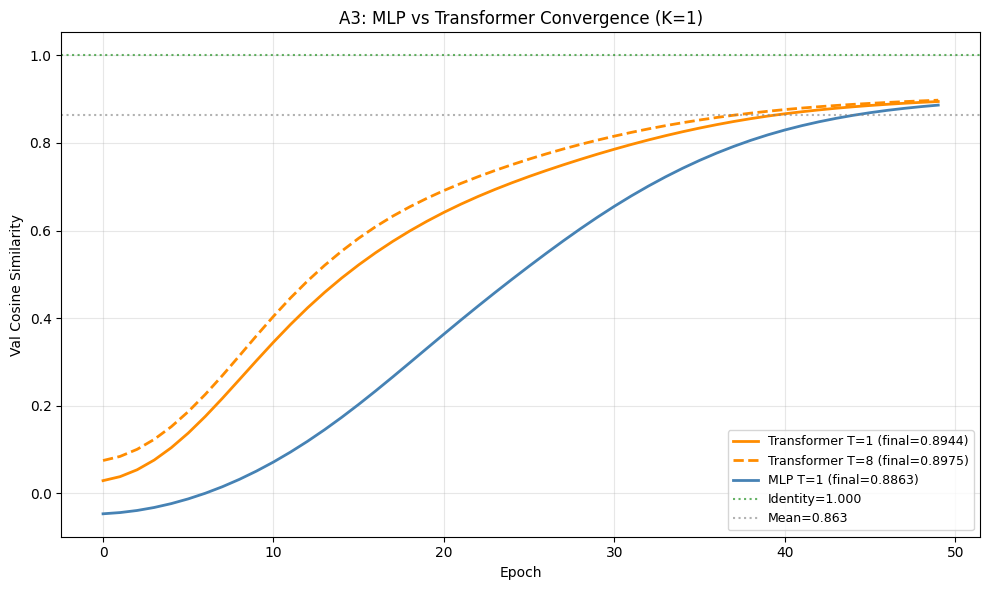

In [26]:
# ── Plot A3: MLP vs Transformer convergence at K=1 ──
fig, ax = plt.subplots(figsize=(10, 6))

# Use context_results[T=1] for fair T=1 comparison
if 1 in context_results:
    ax.plot(context_results[1]['val_cos_list'], color='darkorange', linewidth=2,
            label=f'Transformer T=1 (final={context_results[1]["val_cos"]:.4f})')
if best_T != 1 and best_T in context_results:
    ax.plot(context_results[best_T]['val_cos_list'], color='darkorange', linewidth=2,
            linestyle='--', label=f'Transformer T={best_T} (final={context_results[best_T]["val_cos"]:.4f})')

# Train MLP if we don't have its curve
if mlp_val_cos_list is None:
    print('Training MLP K=1 to get convergence curve...')
    mlp_model2 = MLPPredictor(cfg.embed_dim, cfg.action_dim, cfg.mlp_hidden).to(device)
    mlp_result2 = train_model(mlp_model2, K=1, T=1, verbose=False)
    mlp_val_cos_list = mlp_result2['val_cos_list']
    mlp_val_sim = mlp_result2['val_cos']

ax.plot(mlp_val_cos_list, color='steelblue', linewidth=2,
        label=f'MLP T=1 (final={mlp_val_sim:.4f})')

ax.axhline(y=baselines['identity'], color='green', linestyle=':', alpha=0.6, label=f'Identity={baselines["identity"]:.3f}')
ax.axhline(y=baselines['mean'], color='gray', linestyle=':', alpha=0.6, label=f'Mean={baselines["mean"]:.3f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Cosine Similarity')
ax.set_title('A3: MLP vs Transformer Convergence (K=1)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a3_mlp_vs_transformer.png', dpi=150, bbox_inches='tight')
plt.show()

────────────────────────────────────────────────────────
## A4: Multi-Horizon Training ($K \in \{5, 10, 20\}$)
────────────────────────────────────────────────────────

Train the best predictor (Transformer with best $T$) for each multi-step horizon $K$.

In [27]:
print('=' * 65)
print(f'A4: Multi-Horizon Training (Transformer T={best_T})')
print('=' * 65)

multihorizon_results = {1: {'val_cos': context_results[best_T]['val_cos'],
                             'val_cos_list': context_results[best_T]['val_cos_list'],
                             'best_cos': context_results[best_T]['best_cos'],
                             'model': context_results[best_T]['model']}}

for K in [5, 10, 20]:
    print(f'\n{"─" * 50}')
    print(f'Training Transformer K={K}, T={best_T}')
    print(f'{"─" * 50}')
    model = TransformerPredictor(
        embed_dim=cfg.embed_dim, action_dim=cfg.action_dim, d_model=cfg.d_model,
        n_layers=cfg.n_layers, n_heads=cfg.n_heads, dropout=cfg.dropout,
    ).to(device)
    result = train_model(model, K=K, T=best_T, verbose=True)
    multihorizon_results[K] = result
    print(f'K={K}: final val_cos = {result["val_cos"]:.4f}')

print('\nMulti-horizon training complete.')

A4: Multi-Horizon Training (Transformer T=8)

──────────────────────────────────────────────────
Training Transformer K=5, T=8
──────────────────────────────────────────────────


/tmp/ipykernel_7050/1864248459.py:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(cfg.use_amp and device.type=='cuda'))
/tmp/ipykernel_7050/1864248459.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


E   1/50 | loss=0.9633 | val_cos=0.0506 | best=0.0506 | lr=6.00e-07


/tmp/ipykernel_7050/1864248459.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


E   2/50 | loss=0.9592 | val_cos=0.0624 | best=0.0624 | lr=1.40e-06
E   3/50 | loss=0.9485 | val_cos=0.0826 | best=0.0826 | lr=2.20e-06
E   4/50 | loss=0.9265 | val_cos=0.1109 | best=0.1109 | lr=3.00e-06
E   5/50 | loss=0.9012 | val_cos=0.1462 | best=0.1462 | lr=3.80e-06
E   6/50 | loss=0.8749 | val_cos=0.1872 | best=0.1872 | lr=4.60e-06
E   7/50 | loss=0.8361 | val_cos=0.2319 | best=0.2319 | lr=5.40e-06
E   8/50 | loss=0.7992 | val_cos=0.2781 | best=0.2781 | lr=6.20e-06
E   9/50 | loss=0.7564 | val_cos=0.3237 | best=0.3237 | lr=7.00e-06
E  10/50 | loss=0.7136 | val_cos=0.3674 | best=0.3674 | lr=7.80e-06
E  11/50 | loss=0.6756 | val_cos=0.4082 | best=0.4082 | lr=8.60e-06
E  12/50 | loss=0.6364 | val_cos=0.4458 | best=0.4458 | lr=9.40e-06
E  13/50 | loss=0.6077 | val_cos=0.4806 | best=0.4806 | lr=1.02e-05
E  14/50 | loss=0.5761 | val_cos=0.5128 | best=0.5128 | lr=1.10e-05
E  15/50 | loss=0.5377 | val_cos=0.5424 | best=0.5424 | lr=1.18e-05
E  16/50 | loss=0.5100 | val_cos=0.5698 | best=0

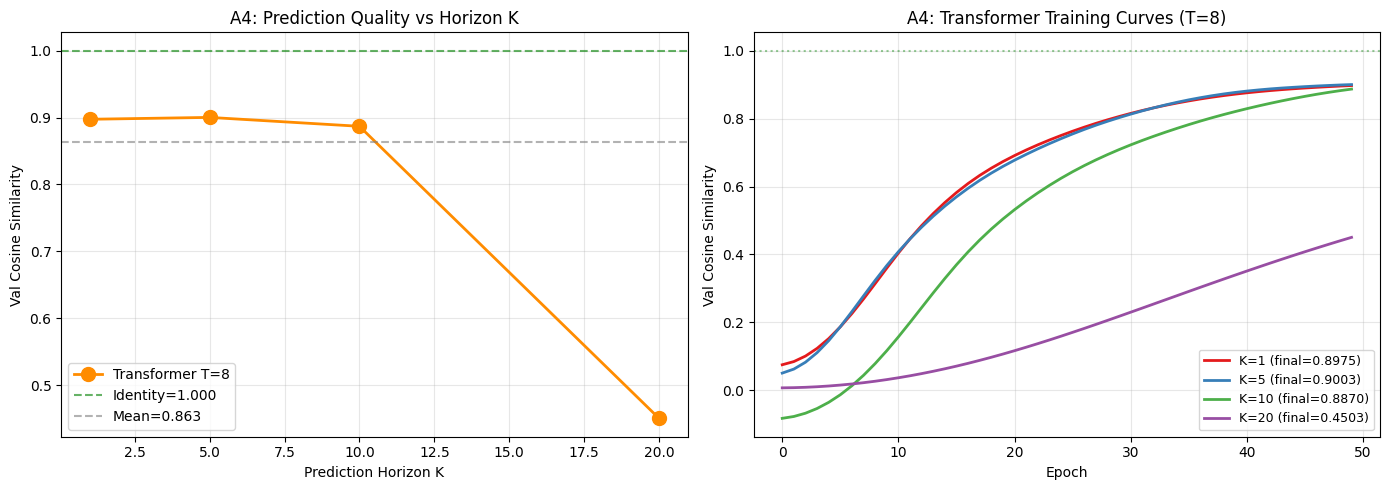


K     Val CosSim    Best CosSim   
----------------------------------
1     0.8975        0.8975        
5     0.9003        0.9003        
10    0.8870        0.8870        
20    0.4503        0.4503        


In [30]:
# ── Plot A4: Multi-Horizon Results ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Val cos_sim vs horizon K
ax = axes[0]
K_vals = [1, 5, 10, 20]
final_cos_list = [multihorizon_results[k]['val_cos'] for k in K_vals]
ax.plot(K_vals, final_cos_list, 'o-', color='darkorange', linewidth=2, markersize=10,
        label=f'Transformer T={best_T}')
ax.axhline(y=baselines['identity'], color='green', linestyle='--', alpha=0.6, label=f'Identity={baselines["identity"]:.3f}')
ax.axhline(y=baselines['mean'], color='gray', linestyle='--', alpha=0.6, label=f'Mean={baselines["mean"]:.3f}')
ax.set_xlabel('Prediction Horizon K')
ax.set_ylabel('Val Cosine Similarity')
ax.set_title('A4: Prediction Quality vs Horizon K')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Training curves for each K
ax = axes[1]
colors_k = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for i, K in enumerate(K_vals):
    ax.plot(multihorizon_results[K]['val_cos_list'], color=colors_k[i], linewidth=2,
            label=f'K={K} (final={multihorizon_results[K]["val_cos"]:.4f})')
ax.axhline(y=baselines['identity'], color='green', linestyle=':', alpha=0.4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Cosine Similarity')
ax.set_title(f'A4: Transformer Training Curves (T={best_T})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a4_multihorizon.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"K":<6}{"Val CosSim":<14}{"Best CosSim":<14}')
print('-' * 34)
for K in K_vals:
    print(f'{K:<6}{multihorizon_results[K]["val_cos"]:<14.4f}{multihorizon_results[K]["best_cos"]:<14.4f}')

────────────────────────────────────────────────────────
## A5: Rollout Drift Evaluation
────────────────────────────────────────────────────────

**Autoregressive rollout**: starting from $z_t$, predict $\hat{z}_{t+K}$, feed prediction back as input, and continue. Measure $\cos(\hat{z}_{t+mK}, z_{t+mK}^*)$ vs. rollout step $m$.

We take expert action sequences from a held-out demo and roll out the predictor autoregressively.

In [31]:
print('=' * 65)
print('A5: Rollout Drift Evaluation')
print('=' * 65)

@torch.no_grad()
def autoregressive_rollout(model, z_start, actions, K, T, max_steps=20):
    """
    Roll out the predictor autoregressively for max_steps * K frames.
    
    Args:
        z_start: initial embedding (384,)
        actions: full action sequence (total_frames, 7) — expert actions
        K: prediction horizon per autoregressive step
        T: context window (we keep last T observations)
        max_steps: max number of autoregressive steps
    Returns:
        pred_embeddings: list of predicted embeddings
        true_embeddings: list of true embeddings at each rollout step
        cos_sims: list of cosine similarities at each step
    """
    model.eval()
    # Build initial context: z_0 is repeated T times
    z_context = z_start.unsqueeze(0).unsqueeze(0).repeat(1, T, 1).to(device)  # (1, T, 384)
    a_context = actions[:1].unsqueeze(0).repeat(1, T, 1)            # (1, T, 7)
    
    pred_embeddings = [z_start.cpu().numpy()]
    true_embeddings = [z_start.cpu().numpy()]
    cos_sims = [1.0]  # first prediction is exact
    
    current_step = 0
    for m in range(1, max_steps + 1):
        target_step = current_step + K
        if target_step >= len(actions):
            break
        # Predict next embedding
        pred = model(z_context.to(device), a_context.to(device))  # (1, 384)
        # Slide context window
        z_context = torch.cat([z_context[:, 1:, :], pred.unsqueeze(1)], dim=1)
        # Use expert action for the target step
        a_new = actions[target_step:target_step+1].unsqueeze(0).repeat(1, T, 1)
        a_context = a_new
        
        pred_embeddings.append(pred.squeeze(0).cpu().numpy())
        true_embeddings.append(embeddings_val[target_step].cpu().numpy())
        cs = F.cosine_similarity(pred.squeeze(0), embeddings_val[target_step].to(device), dim=0).item()
        cos_sims.append(cs)
        current_step = target_step
    
    return pred_embeddings, true_embeddings, cos_sims


# ── Run rollout for each K ──
# Use a val demo (demo index 160 is first val demo)
# Get first frame of first val demo
# We need to load the original frames/actions to know demo boundaries
# For simplicity, use val_embeddings and val_actions directly
embeddings_val = torch.load(EMBED_DIR / 'embeddings_val.pt').float()
actions_val_raw = torch.load(EMBED_DIR / 'actions_val.pt').float()

# Use first ~30 frames of val set as a continuous sequence
start_idx = 0
z_0 = embeddings_val[start_idx]
actions_seq = actions_val_raw[start_idx:start_idx + K * 20 + cfg.T_values[-1]]

rollout_results = {}

for K in cfg.K_values:
    print(f'\nAutoregressive rollout K={K} (T={best_T})...')
    model = multihorizon_results[K]['model']
    _, true_embs, cos_list = autoregressive_rollout(
        model, z_0, actions_seq, K=K, T=best_T, max_steps=10
    )
    rollout_results[K] = {'cos_sims': cos_list, 'true_embs': true_embs}
    print(f'  Steps: {len(cos_list)}, final cos_sim: {cos_list[-1]:.4f}, avg: {np.mean(cos_list):.4f}')

A5: Rollout Drift Evaluation

Autoregressive rollout K=1 (T=8)...
  Steps: 11, final cos_sim: 0.9260, avg: 0.8924

Autoregressive rollout K=5 (T=8)...
  Steps: 11, final cos_sim: 0.8027, avg: 0.8562

Autoregressive rollout K=10 (T=8)...
  Steps: 11, final cos_sim: 0.5406, avg: 0.8489

Autoregressive rollout K=20 (T=8)...
  Steps: 11, final cos_sim: 0.0708, avg: 0.3461


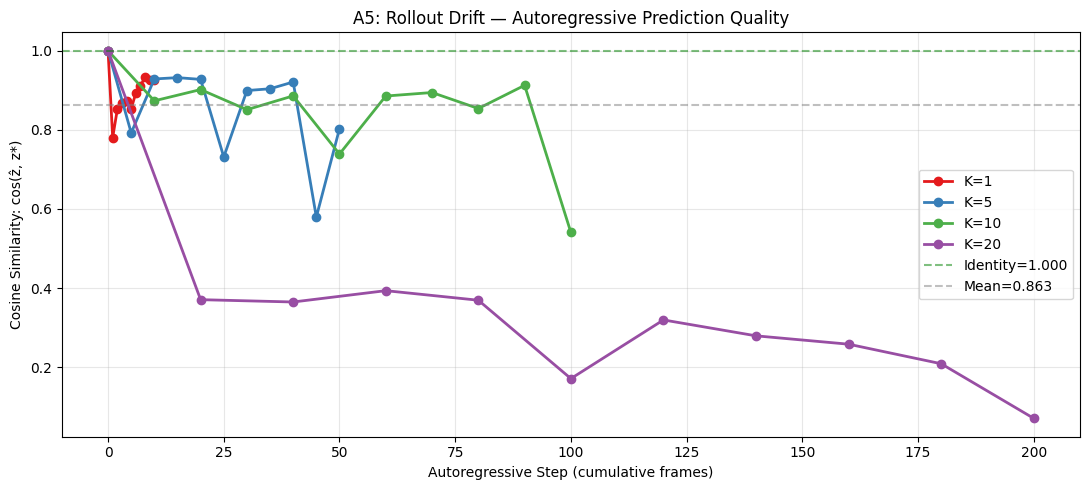


K     Steps     Init cos    Final cos   Avg cos     Drift     
--------------------------------------------------------------
1     11        1.0000      0.9260      0.8924      0.0740    
5     11        1.0000      0.8027      0.8562      0.1973    
10    11        1.0000      0.5406      0.8489      0.4594    
20    11        1.0000      0.0708      0.3461      0.9292    


In [32]:
# ── Plot A5: Rollout Drift Curves ──
fig, ax = plt.subplots(figsize=(11, 5))

colors_k = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for i, K in enumerate(cfg.K_values):
    cos_list = rollout_results[K]['cos_sims']
    steps = np.arange(len(cos_list)) * K  # actual frame offset
    ax.plot(steps, cos_list, 'o-', color=colors_k[i], linewidth=2, markersize=6,
            label=f'K={K}')

ax.axhline(y=baselines['identity'], color='green', linestyle='--', alpha=0.5, label=f'Identity={baselines["identity"]:.3f}')
ax.axhline(y=baselines['mean'], color='gray', linestyle='--', alpha=0.5, label=f'Mean={baselines["mean"]:.3f}')
ax.set_xlabel('Autoregressive Step (cumulative frames)')
ax.set_ylabel('Cosine Similarity: cos(ẑ, z*)')
ax.set_title('A5: Rollout Drift — Autoregressive Prediction Quality')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a5_rollout_drift.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f'\n{"K":<6}{"Steps":<10}{"Init cos":<12}{"Final cos":<12}{"Avg cos":<12}{"Drift":<10}')
print('-' * 62)
for K in cfg.K_values:
    c = rollout_results[K]['cos_sims']
    print(f'{K:<6}{len(c):<10}{c[0]:<12.4f}{c[-1]:<12.4f}{np.mean(c):<12.4f}{c[0]-c[-1]:<10.4f}')

────────────────────────────────────────────────────────
## A6: Action Grounding Ablation
────────────────────────────────────────────────────────

Evaluate the Transformer predictor at $K=1$ with:
- **Full action** (ground truth expert actions)
- **Zero action** (all zeros)
- **Random action** (Gaussian noise)

This verifies that the model actually uses action information.

In [33]:
print('=' * 65)
print('A6: Action Grounding Ablation')
print('=' * 65)

# Use best Transformer (K=1, best T)
model_a6 = context_results[best_T]['model']
_, val_ldr_a6 = build_loaders(K=1, T=best_T)

full_cos = compute_val_cosine_ablation(model_a6, val_ldr_a6, 'full')
zero_cos = compute_val_cosine_ablation(model_a6, val_ldr_a6, 'zero')
random_cos = compute_val_cosine_ablation(model_a6, val_ldr_a6, 'random')

ablation_results = {'full': full_cos, 'zero': zero_cos, 'random': random_cos}

print(f'\nAction Ablation Results (Transformer K=1, T={best_T}):')
print(f'  Full action:   {full_cos:.4f}')
print(f'  Zero action:   {zero_cos:.4f} (Δ = {full_cos - zero_cos:+.4f})')
print(f'  Random action: {random_cos:.4f} (Δ = {full_cos - random_cos:+.4f})')
print(f'  Action contribution: {full_cos - zero_cos:.4f} cos_sim')

A6: Action Grounding Ablation


/tmp/ipykernel_7050/1864248459.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Action Ablation Results (Transformer K=1, T=8):
  Full action:   0.8975
  Zero action:   0.8974 (Δ = +0.0001)
  Random action: 0.8973 (Δ = +0.0001)
  Action contribution: 0.0001 cos_sim


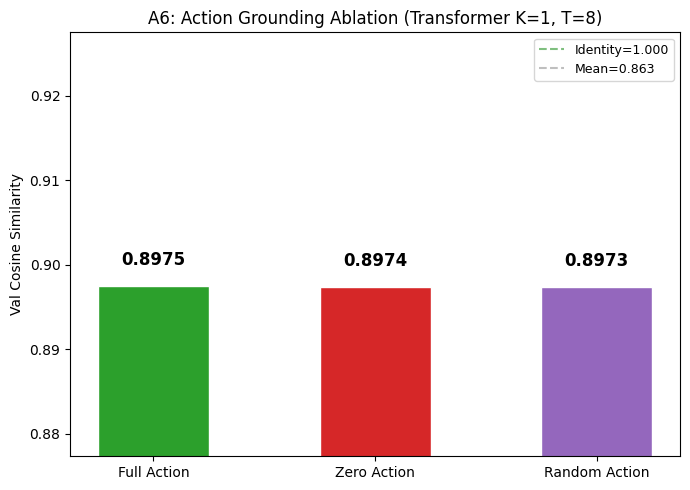

In [34]:
# ── Plot A6: Action Grounding Ablation Bar Chart ──
fig, ax = plt.subplots(figsize=(7, 5))
categories = ['Full Action', 'Zero Action', 'Random Action']
values = [full_cos, zero_cos, random_cos]
colors_bar = ['#2ca02c', '#d62728', '#9467bd']
bars = ax.bar(categories, values, color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.axhline(y=baselines['identity'], color='green', linestyle='--', alpha=0.5, label=f'Identity={baselines["identity"]:.3f}')
ax.axhline(y=baselines['mean'], color='gray', linestyle='--', alpha=0.5, label=f'Mean={baselines["mean"]:.3f}')
ax.set_ylabel('Val Cosine Similarity')
ax.set_title(f'A6: Action Grounding Ablation (Transformer K=1, T={best_T})')
ax.legend(fontsize=9)
ax.set_ylim(min(values) - 0.02, max(values) + 0.03)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'a6_action_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

────────────────────────────────────────────────────────
## Summary & Save All Checkpoints
────────────────────────────────────────────────────────

In [35]:
print('=' * 70)
print('MODULE A: PREDICTOR — COMPLETE SUMMARY')
print('=' * 70)

print(f'\n{"─" * 60}')
print('A1: Transformer Predictor')
print(f'  Architecture: Causal Transformer, d={cfg.d_model}, L={cfg.n_layers}, h={cfg.n_heads}')
print(f'  Action MLP: R^7 → 128 → {cfg.d_model}')
print(f'  Params: {sum(p.numel() for p in TransformerPredictor().parameters()):,}')

print(f'\n{"─" * 60}')
print('A2: Context Ablation (T ∈ {1,2,4,8})')
for T in cfg.T_values:
    print(f'  T={T}: val_cos_sim = {context_results[T]["val_cos"]:.4f}')
print(f'  Best: T={best_T} ({context_results[best_T]["val_cos"]:.4f})')

print(f'\n{"─" * 60}')
print('A3: MLP vs Transformer (K=1)')
print(f'  MLP K=1:             {mlp_val_sim:.4f}')
print(f'  Transformer K=1 (best T={best_T}): {t_val_sim:.4f}')
print(f'  Delta:               {t_val_sim - mlp_val_sim:+.4f}')

print(f'\n{"─" * 60}')
print('A4: Multi-Horizon (K ∈ {1,5,10,20})')
for K in cfg.K_values:
    print(f'  K={K:2d}: val_cos_sim = {multihorizon_results[K]["val_cos"]:.4f}')

print(f'\n{"─" * 60}')
print('A5: Rollout Drift')
for K in cfg.K_values:
    c = rollout_results[K]['cos_sims']
    print(f'  K={K:2d}: steps={len(c)}, init={c[0]:.4f}, final={c[-1]:.4f}, drift={c[0]-c[-1]:.4f}')

print(f'\n{"─" * 60}')
print('A6: Action Grounding Ablation')
print(f'  Full:   {ablation_results["full"]:.4f}')
print(f'  Zero:   {ablation_results["zero"]:.4f} (Δ = {ablation_results["full"]-ablation_results["zero"]:+.4f})')
print(f'  Random: {ablation_results["random"]:.4f} (Δ = {ablation_results["full"]-ablation_results["random"]:+.4f})')

print(f'\n{"─" * 60}')
print('Baselines')
print(f'  Identity: {baselines["identity"]:.4f}')
print(f'  Mean:     {baselines["mean"]:.4f}')
print(f'  Gap:      {baselines["identity"] - baselines["mean"]:.4f}')
print('=' * 70)

MODULE A: PREDICTOR — COMPLETE SUMMARY

────────────────────────────────────────────────────────────
A1: Transformer Predictor
  Architecture: Causal Transformer, d=256, L=4, h=4
  Action MLP: R^7 → 128 → 256
  Params: 5,507,968

────────────────────────────────────────────────────────────
A2: Context Ablation (T ∈ {1,2,4,8})
  T=1: val_cos_sim = 0.8944
  T=2: val_cos_sim = 0.8940
  T=4: val_cos_sim = 0.8955
  T=8: val_cos_sim = 0.8975
  Best: T=8 (0.8975)

────────────────────────────────────────────────────────────
A3: MLP vs Transformer (K=1)
  MLP K=1:             0.8863
  Transformer K=1 (best T=8): 0.8975
  Delta:               +0.0112

────────────────────────────────────────────────────────────
A4: Multi-Horizon (K ∈ {1,5,10,20})
  K= 1: val_cos_sim = 0.8975
  K= 5: val_cos_sim = 0.9003
  K=10: val_cos_sim = 0.8870
  K=20: val_cos_sim = 0.4503

────────────────────────────────────────────────────────────
A5: Rollout Drift
  K= 1: steps=11, init=1.0000, final=0.9260, drift=0.074

In [36]:
# ── Save all checkpoints ──
print('Saving checkpoints...')

for T in cfg.T_values:
    torch.save({
        'model_state_dict': context_results[T]['model'].state_dict(),
        'K': 1, 'T': T, 'val_cos': context_results[T]['val_cos'],
        'config': vars(cfg),
    }, OUTPUT_DIR / f'module_a_transformer_K1_T{T}.pt')

for K in cfg.K_values:
    torch.save({
        'model_state_dict': multihorizon_results[K]['model'].state_dict(),
        'K': K, 'T': best_T, 'val_cos': multihorizon_results[K]['val_cos'],
        'config': vars(cfg),
    }, OUTPUT_DIR / f'module_a_transformer_K{K}_T{best_T}.pt')

# Save results dictionary for later modules
torch.save({
    'context_results': {str(k): {'val_cos': v['val_cos'], 'best_cos': v['best_cos']}
                        for k, v in context_results.items()},
    'multihorizon_results': {str(k): {'val_cos': v['val_cos'], 'best_cos': v['best_cos']}
                             for k, v in multihorizon_results.items()},
    'ablation_results': ablation_results,
    'rollout_results': {str(k): {'cos_sims': v['cos_sims']} for k, v in rollout_results.items()},
    'baselines': baselines,
    'best_T': best_T,
    'mlp_val_sim': mlp_val_sim,
    't_val_sim': t_val_sim,
}, OUTPUT_DIR / 'module_a_results.pt')

print(f'All checkpoints saved to {OUTPUT_DIR}')
print(f'Plots saved: a2_context_ablation.png, a3_mlp_vs_transformer.png, a4_multihorizon.png, a5_rollout_drift.png, a6_action_ablation.png')
print('\nModule A complete!')

Saving checkpoints...
All checkpoints saved to /content/drive/MyDrive/jepa_action/outputs
Plots saved: a2_context_ablation.png, a3_mlp_vs_transformer.png, a4_multihorizon.png, a5_rollout_drift.png, a6_action_ablation.png

Module A complete!
